In [10]:
import scanpy as sc
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

adata = sc.read_h5ad("../data/processed/Filbin_step4.h5ad")
S5 = "~/Downloads/aao4750_filbin_sm_tables5.xlsx"   # <-- adjust path

In [11]:
rng = np.random.default_rng(42)

In [ ]:



# --- Step 4  round-trip (must all pass before Step 5 proceeds) ---
print("shape:", adata.shape, "| expect (2454, 8494)")
print("layers:", sorted(adata.layers.keys()), "| expect ['centered', 'tpm']")
print("obsp:", sorted(adata.obsp.keys()), "| expect correlation_centered, distance_centered")
print("obsm:", sorted(adata.obsm.keys()), "| expect X_tsne_centered")
print("uns step4 keys:", sorted(adata.uns["step4"].keys()) if "step4" in adata.uns else "MISSING")
print()

# Per-patient counts (anchor: MUV5 706, BCH836 527, BCH869 492, BCH1126 299, MUV10 284, MUV1 146)
print("per-patient counts:")
print(adata.obs["patient"].value_counts())
print("sum:", adata.obs["patient"].value_counts().sum(), "| expect 2454")
print()

# X identity + centered sanity (anchors from §7)
X = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
print(f".X mean: {X.mean():.4f} (expect ~1.428 on 2458; slight drift on 2454 OK)")
print(f".X zero fraction: {(X==0).mean():.4f} (expect ~0.544)")
print(f".X range: [{X.min():.2f}, {X.max():.2f}] (expect [0, ~15.15])")

cen = adata.layers["centered"]
cen = cen if isinstance(cen, np.ndarray) else cen.toarray()
print(f"centered std: {cen.std():.4f} (expect ~1.6411)")

# obsp shape + t-SNE coord ranges
C = adata.obsp["correlation_centered"]
print(f"correlation_centered shape: {C.shape} (expect (2454, 2454))")
tsne = adata.obsm["X_tsne_centered"]
print(f"t-SNE X range: [{tsne[:,0].min():.1f}, {tsne[:,0].max():.1f}] (expect ~[-29.8, 35.9])")
print(f"t-SNE Y range: [{tsne[:,1].min():.1f}, {tsne[:,1].max():.1f}] (expect ~[-39.5, 37.1])")

shape: (2454, 8494) | expect (2454, 8494)
layers: ['centered', 'tpm'] | expect ['centered', 'tpm']
obsp: ['correlation_centered', 'distance_centered'] | expect correlation_centered, distance_centered
obsm: ['X_tsne_centered'] | expect X_tsne_centered
uns step4 keys: ['artifacts_removed', 'centered_layer_used', 'distance', 'leaves_global', 'leaves_per_patient', 'linkage_method', 'patient_order', 'tsne_params']

per-patient counts:
MUV5       706
BCH836     527
BCH869     492
BCH1126    299
MUV10      284
MUV1       146
Name: patient, dtype: int64
sum: 2454 | expect 2454

.X mean: 1.4281 (expect ~1.428 on 2458; slight drift on 2454 OK)
.X zero fraction: 0.5440 (expect ~0.544)
.X range: [0.00, 15.15] (expect [0, ~15.15])
centered std: 1.6412 (expect ~1.6411)
correlation_centered shape: (2454, 2454) (expect (2454, 2454))
t-SNE X range: [-29.8, 35.9] (expect ~[-29.8, 35.9])
t-SNE Y range: [-39.5, 37.1] (expect ~[-39.5, 37.1])


In [7]:
genes_in_matrix = set(adata.var_names)

# ---- Filbin Table S5 malignant programs (Filbin-native) ----


df = pd.read_excel(S5, sheet_name="Sheet1", header=None)
hdr = df.iloc[2].tolist()
body = df.iloc[3:].reset_index(drop=True); body.columns = hdr
def col(c):
    v = body[c].dropna().astype(str).str.strip()
    return [g for g in v if g and g != "nan"]

programs = {
    "Cellcycle":    col("Cellcycle"),
    "OC":           col("OC"),
    "AC":           col("AC"),
    "OPC_shared":   col("OPC-shared"),
    "OPC_variable": col("OPC-variable"),
}
programs["P4_OPC_merged"] = list(dict.fromkeys(programs["OPC_shared"] + programs["OPC_variable"]))

# ---- Filbin fig. S3B NM signatures (figure row labels, not in any spreadsheet) ----
nm = {
    "NM_oligodendrocyte": ["PLP1", "MOG", "MOBP", "MBP", "CLDN11"],
    "NM_immune": ["TYROBP", "PTPRC", "HLA-DRA", "P2RY12", "FCGR2A",
                  "CSF1R", "CD74", "CD68", "CD53", "AIF1"],
}

all_sigs = {**programs, **nm}

print(f"{'signature':<22} {'total':>5} {'found':>5} {'frac':>6}   missing")
print("-" * 80)
for name, glist in all_sigs.items():
    found = [g for g in glist if g in genes_in_matrix]
    missing = [g for g in glist if g not in genes_in_matrix]
    frac = len(found) / len(glist)
    miss_str = ", ".join(missing) if missing else "—"
    print(f"{name:<22} {len(glist):>5} {len(found):>5} {frac:>6.2f}   {miss_str}")

# stash the *filtered* lists (only genes present) for scoring
sigs_present = {name: [g for g in glist if g in genes_in_matrix]
                for name, glist in all_sigs.items()}

signature              total found   frac   missing
--------------------------------------------------------------------------------
Cellcycle                 50    50   1.00   —
OC                        50    50   1.00   —
AC                        50    50   1.00   —
OPC_shared                19    19   1.00   —
OPC_variable              50    50   1.00   —
P4_OPC_merged             68    68   1.00   —
NM_oligodendrocyte         5     5   1.00   —
NM_immune                 10    10   1.00   —


/home/kian/anaconda3/envs/dmg-py/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [9]:
# How does score_genes' binning input behave on each substrate?
X = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
Er = adata.layers["centered"]
Er = Er if isinstance(Er, np.ndarray) else Er.toarray()

for name, M in [("X (E)", X), ("centered (Er)", Er)]:
    gene_means = M.mean(axis=0)            # per-gene average = what score_genes bins on
    print(f"--- {name} ---")
    print(f"  gene-mean range: [{gene_means.min():.4f}, {gene_means.max():.4f}]")
    print(f"  gene-mean std:   {gene_means.std():.4f}")
    # simulate the 25-bin cut score_genes uses (pd.cut on ranked means)
    
    bins = pd.cut(pd.Series(gene_means).rank(method="min"), 25, labels=False)
    occupancy = bins.value_counts().sort_index()
    print(f"  25-bin occupancy: min={occupancy.min()}, max={occupancy.max()} genes per bin")
    print(f"  (healthy = ~340 each; degenerate = one bin holds most genes)")
    print()

--- X (E) ---
  gene-mean range: [0.0128, 12.4568]
  gene-mean std:   1.1441
  25-bin occupancy: min=339, max=340 genes per bin
  (healthy = ~340 each; degenerate = one bin holds most genes)

--- centered (Er) ---
  gene-mean range: [-0.0082, 0.0074]
  gene-mean std:   0.0017
  25-bin occupancy: min=339, max=340 genes per bin
  (healthy = ~340 each; degenerate = one bin holds most genes)



In [16]:
# ---------------------------------------------------------------
# 0. Rebuild gene lists (same parse as substep 5.2)
# ---------------------------------------------------------------

df = pd.read_excel(S5, sheet_name="Sheet1", header=None)
hdr = df.iloc[2].tolist(); body = df.iloc[3:].reset_index(drop=True); body.columns = hdr
def col(c):
    v = body[c].dropna().astype(str).str.strip()
    return [g for g in v if g and g != "nan"]
programs = {"Cellcycle": col("Cellcycle"), "OC": col("OC"), "AC": col("AC"),
            "OPC_shared": col("OPC-shared"), "OPC_variable": col("OPC-variable")}
programs["P4_OPC_merged"] = list(dict.fromkeys(programs["OPC_shared"] + programs["OPC_variable"]))
nm = {"NM_oligodendrocyte": ["PLP1","MOG","MOBP","MBP","CLDN11"],
      "NM_immune": ["TYROBP","PTPRC","HLA-DRA","P2RY12","FCGR2A","CSF1R","CD74","CD68","CD53","AIF1"]}
all_sigs = {**programs, **nm}

# ---- substrates + Ea (recomputed on current 2454 cells) ---------
X   = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
Er  = adata.layers["centered"]; Er = Er if isinstance(Er, np.ndarray) else Er.toarray()
tpm = adata.layers["tpm"];      tpm = tpm if isinstance(tpm, np.ndarray) else tpm.toarray()
Ea  = np.log2(tpm.mean(axis=0) + 1.0)

# ---- 25 Ea-bins + lookups ---------------------------------------
gene_names  = np.asarray(adata.var_names)
name_to_idx = {g: i for i, g in enumerate(gene_names)}
bin_id      = pd.qcut(Ea, 25, labels=False, duplicates="drop")
bin_to_genes = {b: np.where(bin_id == b)[0] for b in np.unique(bin_id)}
occ = pd.Series(bin_id).value_counts()
print(f"bins: {bin_id.max()+1} | occupancy min={occ.min()} max={occ.max()}")

# ---- Filbin-exact scorer: bin on Ea, score on substrate M -------
def filbin_score(M, sig_genes, ctrl_size=100, seed=42):
    r = np.random.default_rng(seed)
    sig_idx = [name_to_idx[g] for g in sig_genes if g in name_to_idx]
    ctrl_idx = []
    for gi in sig_idx:
        pool = bin_to_genes[bin_id[gi]]
        ctrl_idx.extend(r.choice(pool, size=min(ctrl_size, len(pool)),
                                 replace=len(pool) < ctrl_size).tolist())
    ctrl_idx = np.array(ctrl_idx)
    return np.asarray(M[:, sig_idx].mean(1) - M[:, ctrl_idx].mean(1)).ravel()

# ---- run 3 methods per signature --------------------------------
results = pd.DataFrame(index=adata.obs_names)
for name, glist in all_sigs.items():
    results[f"{name}__custom_Er"] = filbin_score(Er, glist)
    results[f"{name}__custom_X"]  = filbin_score(X,  glist)
    sc.tl.score_genes(adata, glist, score_name=f"_tmp", ctrl_size=100,
                      n_bins=25, use_raw=False, random_state=42)
    results[f"{name}__scanpy_X"]  = adata.obs["_tmp"].to_numpy()
adata.obs.drop(columns=["_tmp"], inplace=True, errors="ignore")

# store the Filbin-anchor scores (custom_Er) onto adata.obs for downstream use
for name in all_sigs:
    adata.obs[f"score_{name}"] = results[f"{name}__custom_Er"].to_numpy()

# ---- comparison table -------------------------------------------
print(f"\n{'signature':<20}{'cEr~cX':>9}{'cX~spX':>9}{'cEr~spX':>9}")
for name in all_sigs:
    a = results[f"{name}__custom_Er"]; b = results[f"{name}__custom_X"]; c = results[f"{name}__scanpy_X"]
    print(f"{name:<20}{spearmanr(a,b).correlation:>9.4f}"
          f"{spearmanr(b,c).correlation:>9.4f}{spearmanr(a,c).correlation:>9.4f}")


/home/kian/anaconda3/envs/dmg-py/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


bins: 25 | occupancy min=339 max=340

signature              cEr~cX   cX~spX  cEr~spX
Cellcycle              0.6217   0.9779   0.6179
OC                     0.9678   0.9646   0.9068
AC                     0.8340   0.9675   0.8234
OPC_shared             0.9713   0.9888   0.9676
OPC_variable           0.7167   0.9754   0.7005
P4_OPC_merged          0.7562   0.9691   0.7348
NM_oligodendrocyte     0.9070   0.9518   0.8087
NM_immune              0.7646   0.7635   0.5544


In [13]:
stored = adata.var["Ea"].to_numpy()
diff = np.abs(Ea - stored)

# 1. How many genes differ, and by how much?
print(f"genes with |diff| > 1e-4: {(diff > 1e-4).sum()} / {len(diff)}")
print(f"diff distribution: median={np.median(diff):.2e}, 99th pct={np.percentile(diff,99):.2e}, max={diff.max():.2e}")

# 2. Where do the largest diffs sit? Show top 10 offenders with their stored vs recomputed Ea
top = np.argsort(diff)[::-1][:10]
print("\ntop 10 differing genes:")
for i in top:
    print(f"  {adata.var_names[i]:<12} stored={stored[i]:.4f}  recomputed={Ea[i]:.4f}  diff={diff[i]:.4f}")

# 3. Is the recompute systematically higher or lower? (cell-count change would bias one way per gene, ~symmetric overall)
signed = Ea - stored
print(f"\nsigned diff: mean={signed.mean():.2e}, (sign tells us if recompute is systematically hi/lo)")

# 4. Direct test of the cell-count hypothesis: does current matrix have 2454 cells?
print(f"\ncurrent n_cells: {adata.n_obs}  (Ea stored was computed on 2458 at Step 3)")

# 5. Are the top offenders concentrated in MUV5/MUV10 expression? Check one offender's TPM by tumor
g = adata.var_names[top[0]]
gi = list(adata.var_names).index(g)
tpm = adata.layers["tpm"]; tpm = tpm if isinstance(tpm,np.ndarray) else tpm.toarray()
print(f"\noffender '{g}' mean TPM by tumor:")
for pt in adata.obs["patient"].cat.categories if hasattr(adata.obs["patient"],'cat') else adata.obs["patient"].unique():
    mask = (adata.obs["patient"]==pt).to_numpy()
    print(f"  {pt:<10} {tpm[mask, gi].mean():.2f}")

genes with |diff| > 1e-4: 8286 / 8494
diff distribution: median=1.91e-03, 99th pct=1.60e-02, max=1.77e-01

top 10 differing genes:
  BUB1B        stored=4.4241  recomputed=4.2469  diff=0.1773
  STIM1        stored=4.2034  recomputed=4.0450  diff=0.1584
  RAB3C        stored=5.1361  recomputed=5.0069  diff=0.1292
  ITGB3BP      stored=4.9715  recomputed=4.8575  diff=0.1140
  NCAPD2       stored=4.0557  recomputed=3.9554  diff=0.1003
  MKKS         stored=6.0227  recomputed=5.9394  diff=0.0833
  ZMYM5        stored=5.4162  recomputed=5.3392  diff=0.0770
  HIAT1        stored=6.2266  recomputed=6.1498  diff=0.0768
  DNAJC9       stored=6.4200  recomputed=6.3461  diff=0.0739
  PLP2         stored=5.4983  recomputed=5.4285  diff=0.0698

signed diff: mean=-2.62e-05, (sign tells us if recompute is systematically hi/lo)

current n_cells: 2454  (Ea stored was computed on 2458 at Step 3)

offender 'BUB1B' mean TPM by tumor:
  BCH836     4.45
  BCH869     33.66
  BCH1126    12.42
  MUV1       12.

In [14]:
tpm = adata.layers["tpm"]; tpm = tpm if isinstance(tpm,np.ndarray) else tpm.toarray()

# A. Does tpm still sum to 1e6 per cell, or was it renormalized after gene filtering?
cell_sums = tpm.sum(axis=1)
print(f"per-cell TPM sum: median={np.median(cell_sums):.1f}, min={cell_sums.min():.1f}, max={cell_sums.max():.1f}")
print("   (1e6 = original TPM; ~smaller & variable = filtered-then-NOT-renormalized; 1e6 again = renormalized after filter)")

# B. Reconstruct what Ea WOULD be if computed on the SAME 2454 cells from .X instead of tpm layer
#    .X = log2(tpm/10+1).  Invert: tpm_from_X = (2**X - 1)*10
X = adata.X if isinstance(adata.X,np.ndarray) else adata.X.toarray()
tpm_from_X = (np.power(2.0, X) - 1.0) * 10.0
Ea_from_X = np.log2(tpm_from_X.mean(axis=0) + 1.0)
stored = adata.var["Ea"].to_numpy()
d_fromX = np.abs(Ea_from_X - stored)
print(f"\nEa recomputed from .X-inverted-tpm vs stored: max diff = {d_fromX.max():.2e}, median = {np.median(d_fromX):.2e}")

# C. And tpm layer vs .X-inverted tpm: are the two TPM sources even the same?
d_tpm = np.abs(tpm - tpm_from_X)
print(f"tpm layer vs (2^X-1)*10: max abs diff = {d_tpm.max():.4f}, mean = {d_tpm.mean():.6f}")

# D. BUB1B specifically: mean from tpm layer vs from X-inverted
gi = list(adata.var_names).index("BUB1B")
print(f"\nBUB1B mean: tpm_layer={tpm[:,gi].mean():.4f}  X_inverted={tpm_from_X[:,gi].mean():.4f}  -> Ea {np.log2(tpm[:,gi].mean()+1):.4f} vs {np.log2(tpm_from_X[:,gi].mean()+1):.4f}")

per-cell TPM sum: median=951915.5, min=827230.2, max=988987.2
   (1e6 = original TPM; ~smaller & variable = filtered-then-NOT-renormalized; 1e6 again = renormalized after filter)

Ea recomputed from .X-inverted-tpm vs stored: max diff = 1.77e-01, median = 1.91e-03
tpm layer vs (2^X-1)*10: max abs diff = 0.0781, mean = 0.000012

BUB1B mean: tpm_layer=17.9862  X_inverted=17.9862  -> Ea 4.2469 vs 4.2469


In [17]:
# NM identity signatures: use the .X (absolute) substrate, not Er
for nm_name in ["NM_oligodendrocyte", "NM_immune"]:
    adata.obs[f"score_{nm_name}"] = results[f"{nm_name}__custom_X"].to_numpy()

# confirm what's now stored
score_cols = [c for c in adata.obs.columns if c.startswith("score_")]
print("stored score columns:", score_cols)
print(adata.obs[score_cols].describe().T[["mean","std","min","max"]].round(3))

stored score columns: ['score_Cellcycle', 'score_OC', 'score_AC', 'score_OPC_shared', 'score_OPC_variable', 'score_P4_OPC_merged', 'score_NM_oligodendrocyte', 'score_NM_immune']
                           mean    std    min    max
score_Cellcycle          -0.001  1.030 -1.863  5.253
score_OC                  0.000  0.777 -1.355  4.362
score_AC                 -0.003  1.315 -2.267  5.112
score_OPC_shared          0.001  1.095 -3.294  2.704
score_OPC_variable        0.000  0.713 -2.838  2.954
score_P4_OPC_merged       0.001  0.620 -2.476  2.368
score_NM_oligodendrocyte -1.775  1.837 -3.818  7.406
score_NM_immune          -1.387  1.326 -2.422  6.299


In [18]:
# How many cells sit in the NM tails, and who are they?
for nm_name, thresh in [("score_NM_oligodendrocyte", 2.0), ("score_NM_immune", 2.0)]:
    s = adata.obs[nm_name]
    hi = adata.obs.index[s > thresh]
    print(f"\n{nm_name} > {thresh}: {len(hi)} cells")
    print(f"  by tumor: {adata.obs.loc[hi, 'patient'].value_counts().to_dict()}")
    # show the top few with their score
    top = s.sort_values(ascending=False).head(8)
    for cell, val in top.items():
        print(f"    {cell:<22} {val:.2f}  ({adata.obs.loc[cell,'patient']})")

# Cross-check: do oligo-high and immune-high overlap? (shouldn't — different cell types)
oligo_hi = set(adata.obs.index[adata.obs["score_NM_oligodendrocyte"] > 2.0])
immune_hi = set(adata.obs.index[adata.obs["score_NM_immune"] > 2.0])
print(f"\noligo-high: {len(oligo_hi)}, immune-high: {len(immune_hi)}, overlap: {len(oligo_hi & immune_hi)}")


score_NM_oligodendrocyte > 2.0: 119 cells
  by tumor: {'MUV5': 59, 'BCH836': 34, 'BCH1126': 19, 'MUV1': 5, 'BCH869': 2, 'MUV10': 0}
    MUV5-P05-A02           7.41  (MUV5)
    MUV5-P03-C04           7.24  (MUV5)
    MUV5-P02-G12           6.89  (MUV5)
    MUV5-P04-H04           6.78  (MUV5)
    MUV5-P05-F08           6.73  (MUV5)
    MUV5-P06-G03           6.64  (MUV5)
    MUV5-P04-D03           6.63  (MUV5)
    MUV5-P03-F12           6.58  (MUV5)

score_NM_immune > 2.0: 85 cells
  by tumor: {'BCH836': 52, 'BCH1126': 32, 'BCH869': 1, 'MUV1': 0, 'MUV5': 0, 'MUV10': 0}
    BCH836-P05-H07         6.30  (BCH836)
    BCH1126-P01-F07        6.28  (BCH1126)
    BCH1126-P04-G06        6.22  (BCH1126)
    BCH836-P02-B11         6.19  (BCH836)
    BCH836-P04-E10         6.16  (BCH836)
    BCH836-P05-H12         6.13  (BCH836)
    BCH836-P03-B01         6.13  (BCH836)
    BCH836-P04-A07         6.12  (BCH836)

oligo-high: 119, immune-high: 85, overlap: 0


In [19]:
# For oligo-high cells: are they ALSO high on the malignant OC program?
# (malignant OC-like cancer cell -> high both; normal oligodendrocyte -> high NM_oligo, not malignant-patterned)
oligo_hi = adata.obs["score_NM_oligodendrocyte"] > 2.0

print("OLIGO-HIGH cells — do they co-score on the malignant OC program?")
print(adata.obs.loc[oligo_hi, ["score_NM_oligodendrocyte","score_OC","score_AC",
                                "score_OPC_shared","score_Cellcycle"]].describe().T[["mean","std"]].round(2))

# Split MUV5 oligo-high specifically (the fig.S4 OC-like-cancer suspects) vs other tumors' oligo-high
muv5_oh = oligo_hi & (adata.obs["patient"]=="MUV5")
other_oh = oligo_hi & (adata.obs["patient"]!="MUV5")
print(f"\nMUV5 oligo-high (n={muv5_oh.sum()}): mean score_OC = {adata.obs.loc[muv5_oh,'score_OC'].mean():.2f}")
print(f"non-MUV5 oligo-high (n={other_oh.sum()}): mean score_OC = {adata.obs.loc[other_oh,'score_OC'].mean():.2f}")

# Immune-high: should NOT co-score on any malignant program if truly immune
immune_hi = adata.obs["score_NM_immune"] > 2.0
print(f"\nIMMUNE-HIGH cells (n={immune_hi.sum()}) — mean malignant-program scores (expect all near/below 0 if truly immune):")
print(adata.obs.loc[immune_hi, ["score_OC","score_AC","score_OPC_shared","score_Cellcycle"]].mean().round(2).to_dict())

OLIGO-HIGH cells — do they co-score on the malignant OC program?
                          mean   std
score_NM_oligodendrocyte  5.37  1.16
score_OC                  2.39  0.64
score_AC                 -0.21  0.42
score_OPC_shared         -2.09  0.70
score_Cellcycle          -0.20  0.29

MUV5 oligo-high (n=59): mean score_OC = 2.56
non-MUV5 oligo-high (n=60): mean score_OC = 2.23

IMMUNE-HIGH cells (n=85) — mean malignant-program scores (expect all near/below 0 if truly immune):
{'score_OC': -0.6000000238418579, 'score_AC': 0.7400000095367432, 'score_OPC_shared': -0.8799999952316284, 'score_Cellcycle': 0.11999999731779099}


In [20]:
# ---------------------------------------------------------------
# Load the raw cohort and extract the 138 pre-tagged Oligo cells
# ---------------------------------------------------------------
raw = sc.read_h5ad("../data/processed/Filbin_cohort_raw.h5ad")
print("raw cohort:", raw.shape)

# find the Oligo group — check obs columns for the tag
print("obs columns:", [c for c in raw.obs.columns])
# (adjust the next line to whatever column/value tags the 138 Oligo cells)
oligo_mask = raw.obs["group"].astype(str).str.contains("Oligo", case=False, na=False) \
    if "group" in raw.obs.columns else None

raw cohort: (4058, 23686)
obs columns: ['sample', 'patient', 'source', 'model', 'is_paper_patient', 'in_paper_cohort', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'hk_score', 'hk_score_hounkpe']


In [21]:
# Cross-tab the candidate flags to locate the non-malignant oligo group
print("in_paper_cohort value counts:")
print(raw.obs["in_paper_cohort"].value_counts(dropna=False))

print("\nsource value counts:")
print(raw.obs["source"].value_counts(dropna=False))

print("\nmodel value counts:")
print(raw.obs["model"].value_counts(dropna=False))

# The 138 should be: patient-derived (not model), NOT in paper cohort
print("\n--- cross-tabs to find the 138 ---")
print("source x in_paper_cohort:")
print(pd.crosstab(raw.obs["source"], raw.obs["in_paper_cohort"], dropna=False))

print("\nis_paper_patient x in_paper_cohort:")
print(pd.crosstab(raw.obs["is_paper_patient"], raw.obs["in_paper_cohort"], dropna=False))

in_paper_cohort value counts:
True     2458
False    1600
Name: in_paper_cohort, dtype: int64

source value counts:
patient          3057
model             863
non-malignant     138
Name: source, dtype: int64

model value counts:
primary_tumor      3057
GS                  290
PDX                 167
DGC75               165
oligodendrocyte     138
DGC100               89
SF                   84
GF                   68
Name: model, dtype: int64

--- cross-tabs to find the 138 ---
source x in_paper_cohort:
in_paper_cohort  False  True 
source                       
model              863      0
non-malignant      138      0
patient            599   2458

is_paper_patient x in_paper_cohort:
in_paper_cohort   False  True 
is_paper_patient              
False               737      0
True                863   2458


In [22]:
# ---------------------------------------------------------------
# Reference: the 138 known non-malignant oligodendrocytes
# ---------------------------------------------------------------
ref = raw[raw.obs["source"] == "non-malignant"].copy()
print(f"reference non-malignant oligos: {ref.n_obs} cells")

# Subset to OUR 8,494 frozen genes, in the same order as adata
common = [g for g in adata.var_names if g in set(ref.var_names)]
assert len(common) == adata.n_vars, f"gene mismatch: {len(common)} vs {adata.n_vars}"
ref = ref[:, adata.var_names].copy()           # reorder to match exactly

# Build E = log2(TPM/10 + 1) for the reference (raw holds TPM in .X)
ref_tpm = ref.X if isinstance(ref.X, np.ndarray) else ref.X.toarray()
ref_E = np.log2(ref_tpm / 10.0 + 1.0)

# Score reference on NM signatures using the SAME custom scorer + SAME Ea bins.
# (Ea bins were built from the 2,454 cohort; we reuse them so controls are
#  drawn from an identical expression-stratified scheme. This is the correct
#  comparison: same control universe, only the cells differ.)
def filbin_score_on(M, sig_genes, ctrl_size=100, seed=42):
    r = np.random.default_rng(seed)
    sig_idx = [name_to_idx[g] for g in sig_genes if g in name_to_idx]
    ctrl_idx = []
    for gi in sig_idx:
        pool = bin_to_genes[bin_id[gi]]
        ctrl_idx.extend(r.choice(pool, size=min(ctrl_size, len(pool)),
                                 replace=len(pool) < ctrl_size).tolist())
    return np.asarray(M[:, sig_idx].mean(1) - M[:, np.array(ctrl_idx)].mean(1)).ravel()

ref_scores = {}
for nm_name, glist in {"NM_oligodendrocyte": nm["NM_oligodendrocyte"],
                       "NM_immune": nm["NM_immune"],
                       "OC": programs["OC"],
                       "AC": programs["AC"],
                       "OPC_shared": programs["OPC_shared"],
                       "Cellcycle": programs["Cellcycle"]}.items():
    ref_scores[nm_name] = filbin_score_on(ref_E, glist)

ref_df = pd.DataFrame(ref_scores, index=ref.obs_names)

# ---------------------------------------------------------------
# THE COMPARISON: reference normal oligos vs our in-cohort suspects
# ---------------------------------------------------------------
oligo_hi = adata.obs["score_NM_oligodendrocyte"] > 2.0
immune_hi = adata.obs["score_NM_immune"] > 2.0

print("\n=== mean (std) NM_oligo / OC / OPC_shared / Cellcycle by group ===")
def row(label, nmo, oc, opc, cc):
    print(f"{label:<32} NM_oligo={nmo:6.2f}  OC={oc:6.2f}  OPC_sh={opc:6.2f}  CC={cc:6.2f}")

row("REFERENCE normal oligos (138)",
    ref_df["NM_oligodendrocyte"].mean(), ref_df["OC"].mean(),
    ref_df["OPC_shared"].mean(), ref_df["Cellcycle"].mean())
row("in-cohort oligo-high (119)",
    adata.obs.loc[oligo_hi,"score_NM_oligodendrocyte"].mean(), adata.obs.loc[oligo_hi,"score_OC"].mean(),
    adata.obs.loc[oligo_hi,"score_OPC_shared"].mean(), adata.obs.loc[oligo_hi,"score_Cellcycle"].mean())
row("in-cohort bulk (all 2454)",
    adata.obs["score_NM_oligodendrocyte"].mean(), adata.obs["score_OC"].mean(),
    adata.obs["score_OPC_shared"].mean(), adata.obs["score_Cellcycle"].mean())

print(f"\nREFERENCE normal oligos: NM_immune mean = {ref_df['NM_immune'].mean():.2f} (expect low — they're oligos not immune)")
print(f"in-cohort immune-high:   NM_immune mean = {adata.obs.loc[immune_hi,'score_NM_immune'].mean():.2f}")

reference non-malignant oligos: 138 cells

=== mean (std) NM_oligo / OC / OPC_shared / Cellcycle by group ===
REFERENCE normal oligos (138)    NM_oligo=  5.18  OC=  1.48  OPC_sh= -0.96  CC= -0.85
in-cohort oligo-high (119)       NM_oligo=  5.37  OC=  2.39  OPC_sh= -2.09  CC= -0.20
in-cohort bulk (all 2454)        NM_oligo= -1.78  OC=  0.00  OPC_sh=  0.00  CC= -0.00

REFERENCE normal oligos: NM_immune mean = -1.39 (expect low — they're oligos not immune)
in-cohort immune-high:   NM_immune mean = 5.34


In [23]:
# ---------------------------------------------------------------
# Persist Step 5 NM analysis into adata.uns for Step 6 (CNV) reuse
# ---------------------------------------------------------------
oligo_hi = (adata.obs["score_NM_oligodendrocyte"] > 2.0)
immune_hi = (adata.obs["score_NM_immune"] > 2.0)

adata.uns["step5_nm"] = {
    # --- the 138-cell non-malignant reference (Step 6 CNV-negative control) ---
    "reference_oligo_cells": np.asarray(ref.obs_names, dtype=object),     # 138 cell IDs
    "reference_scores": {                                                 # plain dict of arrays
        k: np.asarray(v, dtype=np.float32) for k, v in ref_df.items()
    },
    # --- in-cohort NM candidate pools (flagged, NOT classified — Step 6 decides) ---
    "oligo_high_cells": np.asarray(adata.obs_names[oligo_hi], dtype=object),    # 119
    "immune_high_cells": np.asarray(adata.obs_names[immune_hi], dtype=object),  # 85
    "nm_threshold": 2.0,
    # --- the key Step 5 finding, recorded as group-level summary stats ---
    "group_summary": {
        "reference_oligo":  {"n": int(ref.n_obs),
                             "NM_oligo": float(ref_df["NM_oligodendrocyte"].mean()),
                             "OC": float(ref_df["OC"].mean()),
                             "OPC_shared": float(ref_df["OPC_shared"].mean()),
                             "Cellcycle": float(ref_df["Cellcycle"].mean())},
        "cohort_oligo_high": {"n": int(oligo_hi.sum()),
                             "NM_oligo": float(adata.obs.loc[oligo_hi,"score_NM_oligodendrocyte"].mean()),
                             "OC": float(adata.obs.loc[oligo_hi,"score_OC"].mean()),
                             "OPC_shared": float(adata.obs.loc[oligo_hi,"score_OPC_shared"].mean()),
                             "Cellcycle": float(adata.obs.loc[oligo_hi,"score_Cellcycle"].mean())},
        "cohort_immune_high": {"n": int(immune_hi.sum()),
                             "NM_immune": float(adata.obs.loc[immune_hi,"score_NM_immune"].mean())},
    },
    "finding": ("Marker/program scores cannot separate malignant OC-like from "
                "non-malignant oligodendrocytes: reference normal oligos score OC=1.48 "
                "(positive) due to gene overlap with NM_oligo markers; in-cohort oligo-high "
                "lean more malignant (OC=2.39, OPC_sh=-2.09) but distributions overlap. "
                "Malignant/NM classification deferred to Step 6 (CNV, orthogonal to expression)."),
}

# verify it round-trips
import tempfile, os
tmp = os.path.join(tempfile.gettempdir(), "uns_roundtrip_test.h5ad")
adata.write_h5ad(tmp)
chk = sc.read_h5ad(tmp)
assert "step5_nm" in chk.uns
assert len(chk.uns["step5_nm"]["reference_oligo_cells"]) == 138
assert len(chk.uns["step5_nm"]["oligo_high_cells"]) == 119
assert len(chk.uns["step5_nm"]["immune_high_cells"]) == 85
print("uns['step5_nm'] round-trips cleanly:")
print(f"  reference oligos: {len(chk.uns['step5_nm']['reference_oligo_cells'])}")
print(f"  oligo-high: {len(chk.uns['step5_nm']['oligo_high_cells'])}")
print(f"  immune-high: {len(chk.uns['step5_nm']['immune_high_cells'])}")
print(f"  reference score keys: {list(chk.uns['step5_nm']['reference_scores'].keys())}")
os.remove(tmp)

uns['step5_nm'] round-trips cleanly:
  reference oligos: 138
  oligo-high: 119
  immune-high: 85
  reference score keys: ['AC', 'Cellcycle', 'NM_immune', 'NM_oligodendrocyte', 'OC', 'OPC_shared']


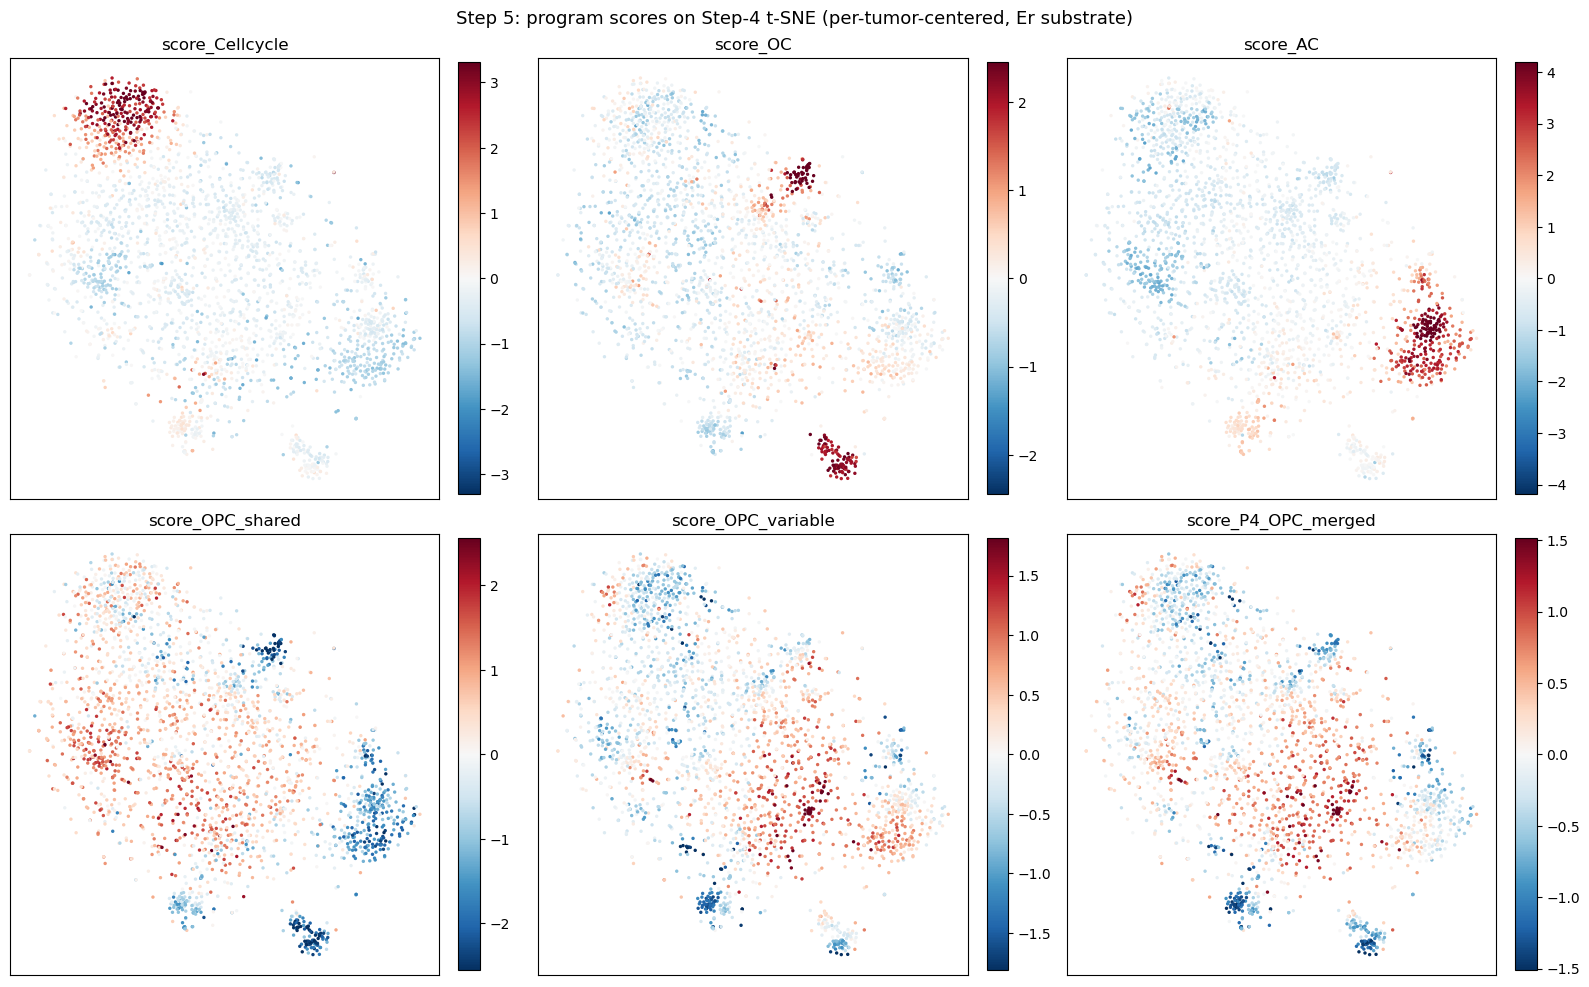

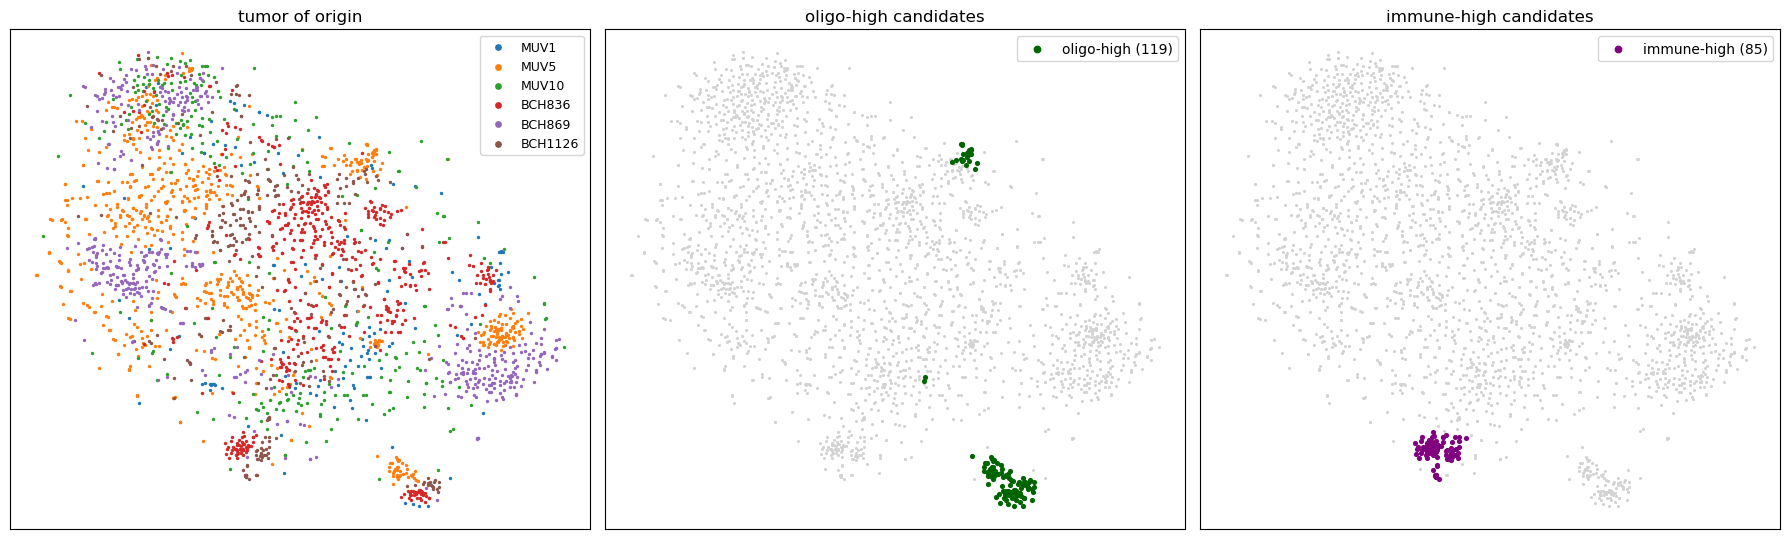

cell-cycle-high cells (score>1.0): 281
by tumor:
BCH869     105
MUV10       70
MUV5        62
BCH1126     22
BCH836      17
MUV1         5
Name: patient, dtype: int64

t-SNE location of cell-cycle-high cells:
  X: mean=-13.8 (full range [-29.8, 35.9])
  Y: mean=26.5 (full range [-39.5, 37.1])


In [25]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../figures/step5", exist_ok=True)
tsne = adata.obsm["X_tsne_centered"]   # Step 4 coords (frozen anchor)

# ---------------------------------------------------------------
# Panel 1: six program scores on the t-SNE
# ---------------------------------------------------------------
programs_to_plot = ["Cellcycle", "OC", "AC", "OPC_shared", "OPC_variable", "P4_OPC_merged"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, prog in zip(axes.flat, programs_to_plot):
    s = adata.obs[f"score_{prog}"].to_numpy()
    # symmetric color scale around 0 (scores are centered); robust limits
    vmax = np.percentile(np.abs(s), 98)
    sca = ax.scatter(tsne[:,0], tsne[:,1], c=s, cmap="RdBu_r",
                     vmin=-vmax, vmax=vmax, s=6, linewidths=0)
    ax.set_title(f"score_{prog}", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Step 5: program scores on Step-4 t-SNE (per-tumor-centered, Er substrate)", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/step5/program_scores_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------
# Panel 2: tumor-of-origin + NM candidates for reference
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) tumor of origin
for pt in adata.obs["patient"].unique():
    m = (adata.obs["patient"] == pt).to_numpy()
    axes[0].scatter(tsne[m,0], tsne[m,1], s=6, label=pt, linewidths=0)
axes[0].legend(markerscale=2, fontsize=9); axes[0].set_title("tumor of origin")
axes[0].set_xticks([]); axes[0].set_yticks([])

# (b) oligo-high candidates (119)
oh = (adata.obs["score_NM_oligodendrocyte"] > 2.0).to_numpy()
axes[1].scatter(tsne[~oh,0], tsne[~oh,1], s=5, c="lightgray", linewidths=0)
axes[1].scatter(tsne[oh,0], tsne[oh,1], s=14, c="darkgreen", linewidths=0, label=f"oligo-high ({oh.sum()})")
axes[1].legend(markerscale=1.5); axes[1].set_title("oligo-high candidates")
axes[1].set_xticks([]); axes[1].set_yticks([])

# (c) immune-high candidates (85)
ih = (adata.obs["score_NM_immune"] > 2.0).to_numpy()
axes[2].scatter(tsne[~ih,0], tsne[~ih,1], s=5, c="lightgray", linewidths=0)
axes[2].scatter(tsne[ih,0], tsne[ih,1], s=14, c="purple", linewidths=0, label=f"immune-high ({ih.sum()})")
axes[2].legend(markerscale=1.5); axes[2].set_title("immune-high candidates")
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.savefig("../figures/step5/tumor_and_nm_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------
# Quantitative check: WHERE is cell-cycle high? Is it cross-tumor?
# ---------------------------------------------------------------
cc_hi = (adata.obs["score_Cellcycle"] > 1.0).to_numpy()
print(f"cell-cycle-high cells (score>1.0): {cc_hi.sum()}")
print("by tumor:")
print(adata.obs.loc[cc_hi, "patient"].value_counts())
print(f"\nt-SNE location of cell-cycle-high cells:")
print(f"  X: mean={tsne[cc_hi,0].mean():.1f} (full range [{tsne[:,0].min():.1f}, {tsne[:,0].max():.1f}])")
print(f"  Y: mean={tsne[cc_hi,1].mean():.1f} (full range [{tsne[:,1].min():.1f}, {tsne[:,1].max():.1f}])")

rows per block: {'P1_Cellcycle': 30, 'P2_AC': 30, 'P3_OC': 30, 'P4_OPC': 19} | total rows: 109
clustered 2454 cells on 6 program scores


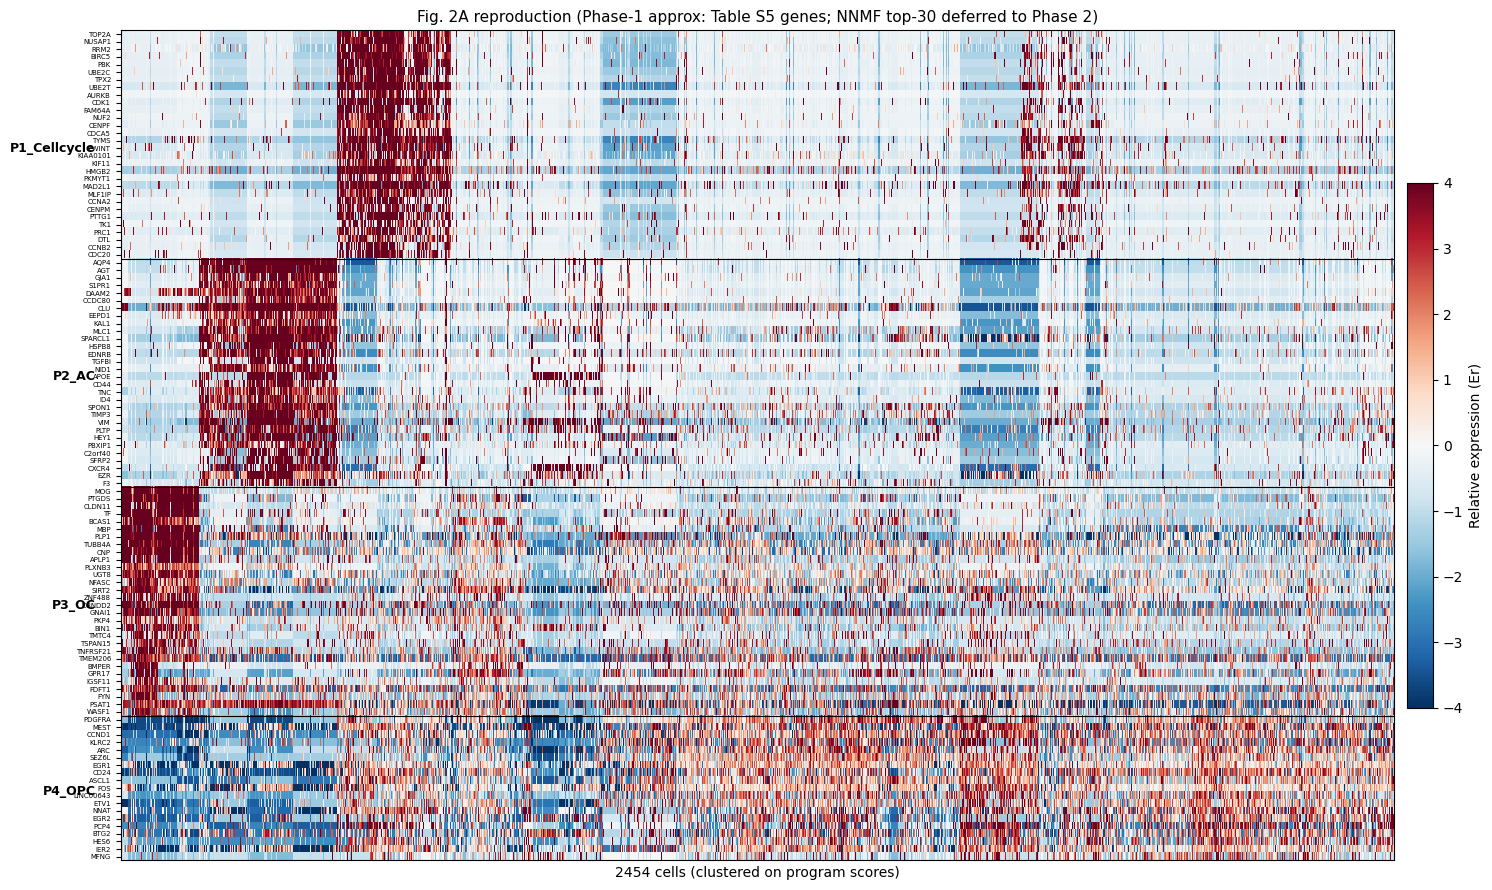

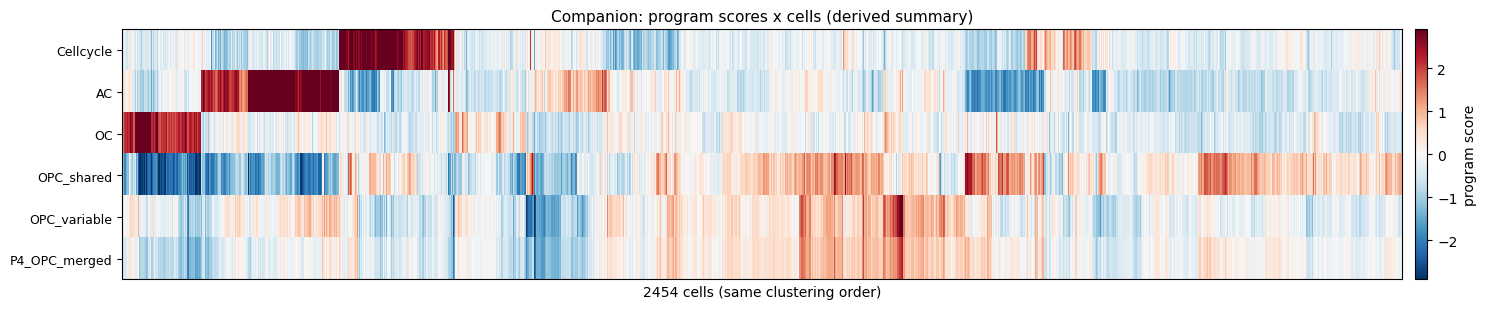

In [26]:
import scanpy as sc, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
import os

# ---------------------------------------------------------------
# 1. Pick heatmap row genes: top 30 per program by correlation to
#    that program's score (Phase-1 analog of Filbin's top-30-by-
#    correlation-to-NNMF-meta-program). P4 uses all 19 (as Filbin).
#    >>> TAG: Phase-2 = re-derive these 30 from NNMF meta-programs <
# ---------------------------------------------------------------
Er = adata.layers["centered"]; Er = Er if isinstance(Er, np.ndarray) else Er.toarray()
gidx = {g: i for i, g in enumerate(adata.var_names)}

def top_genes_by_corr(sig_genes, score_vec, n):
    # correlate each signature gene's Er profile with the program score, take top n
    cand = [g for g in sig_genes if g in gidx]
    cors = {g: np.corrcoef(Er[:, gidx[g]], score_vec)[0, 1] for g in cand}
    return [g for g, _ in sorted(cors.items(), key=lambda kv: kv[1], reverse=True)[:n]]

row_blocks = {
    "P1_Cellcycle": top_genes_by_corr(programs["Cellcycle"], adata.obs["score_Cellcycle"].values, 30),
    "P2_AC":        top_genes_by_corr(programs["AC"],        adata.obs["score_AC"].values, 30),
    "P3_OC":        top_genes_by_corr(programs["OC"],        adata.obs["score_OC"].values, 30),
    "P4_OPC":       [g for g in programs["OPC_shared"] if g in gidx],   # all 19
}
row_genes = sum(row_blocks.values(), [])
row_labels_block = sum([[k]*len(v) for k, v in row_blocks.items()], [])
print("rows per block:", {k: len(v) for k, v in row_blocks.items()}, "| total rows:", len(row_genes))

# ---------------------------------------------------------------
# 2. Cluster cells on the 6 program scores (faithful analog)
# ---------------------------------------------------------------
score_cols = ["score_Cellcycle","score_AC","score_OC",
              "score_OPC_shared","score_OPC_variable","score_P4_OPC_merged"]
S = adata.obs[score_cols].to_numpy()
Z = linkage(S, method="ward")
order = leaves_list(Z)                      # cell column order
print(f"clustered {len(order)} cells on {len(score_cols)} program scores")

# ---------------------------------------------------------------
# 3. FIGURE 1 — faithful Fig.2A: genes (rows) x cells (cols), Er
# ---------------------------------------------------------------
M = Er[np.ix_(order, [gidx[g] for g in row_genes])].T    # genes x cells
fig, ax = plt.subplots(figsize=(15, 9))
im = ax.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-4, vmax=4, interpolation="nearest")
ax.set_yticks(range(len(row_genes))); ax.set_yticklabels(row_genes, fontsize=5)
ax.set_xticks([]); ax.set_xlabel(f"{len(order)} cells (clustered on program scores)")
# block separators on rows
boundary = np.cumsum([len(v) for v in row_blocks.values()])[:-1]
for b in boundary: ax.axhline(b-0.5, color="k", lw=0.8)
for k, ypos in zip(row_blocks, np.cumsum([0]+[len(v) for v in row_blocks.values()])[:-1]):
    ax.text(-len(order)*0.02, ypos+len(row_blocks[k])/2, k, ha="right", va="center", fontsize=9, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="Relative expression (Er)")
ax.set_title("Fig. 2A reproduction (Phase-1 approx: Table S5 genes; NNMF top-30 deferred to Phase 2)", fontsize=11)
plt.tight_layout(); plt.savefig("../figures/step5/fig2A_faithful.png", dpi=150, bbox_inches="tight"); plt.show()

# ---------------------------------------------------------------
# 4. FIGURE 2 — companion score heatmap: 6 programs x cells
# ---------------------------------------------------------------
SC = adata.obs[score_cols].to_numpy()[order].T
fig, ax = plt.subplots(figsize=(15, 3.2))
vmax = np.percentile(np.abs(SC), 98)
im = ax.imshow(SC, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_yticks(range(len(score_cols))); ax.set_yticklabels([c.replace("score_","") for c in score_cols], fontsize=9)
ax.set_xticks([]); ax.set_xlabel(f"{len(order)} cells (same clustering order)")
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="program score")
ax.set_title("Companion: program scores x cells (derived summary)", fontsize=11)
plt.tight_layout(); plt.savefig("../figures/step5/fig2A_score_companion.png", dpi=150, bbox_inches="tight"); plt.show()